# Exercises XP Ninja - Image Compression with K-Means and PCA

## What you will learn
- Image compression with K-Means on RGB pixels
- Dimensionality reduction with PCA

## What you will create
- Compressed image with reduced color palette
- PCA projection and recovery plots


### Provided helpers
Use these functions for K-Means. Do not modify them.

In [ ]:
import numpy as np

def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)

def find_closest_centroids(X, centroids):
    diffs = X[:, None, :] - centroids[None, :, :]
    d2 = np.sum(diffs * diffs, axis=2)
    return np.argmin(d2, axis=1)

def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    C = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.size == 0:
            C[k] = X[rng.integers(0, m)]
        else:
            C[k] = pts.mean(axis=0)
    return C

def run_k_means(X, init_C, max_iters=10, rng=None):
    K = init_C.shape[0]
    C = init_C.copy().astype(float)
    history = [C.copy()]
    idx = None
    for _ in range(max_iters):
        idx = find_closest_centroids(X, C)
        C = compute_centroids(X, idx, K, rng=rng)
        history.append(C.copy())
    return C, idx, history

## Task 1 - Load and preprocess image from `bird_small.mat`
- Load with `scipy.io.loadmat`
- Normalize to [0,1] by dividing by 255
- Reshape image to a 2D array of RGB pixels shape (m, 3)

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

mat = loadmat('bird_small.mat')
# The variable is usually 'A' with shape (H, W, 3)
A = mat.get('A', None)
if A is None:
    # Fallback: try common keys or raise
    for k in mat.keys():
        if isinstance(mat[k], np.ndarray) and mat[k].ndim == 3 and mat[k].shape[2] == 3:
            A = mat[k]; break
if A is None:
    raise ValueError('Could not find 3D RGB array in bird_small.mat')

# TODO: normalize to [0,1] and reshape to pixels X of shape (m, 3)
A_norm = A / 255.0  # Normalize to [0,1]
X_img = A_norm.reshape(-1, 3) # Reshape to (m, 3)
print('Image shape:', A.shape, 'Pixels shape:', X_img.shape)

# Optional: show original image
# plt.imshow(A_norm); plt.title('Original normalized'); plt.axis('off'); plt.show()

## Task 2 - K-Means image compression
- Choose K and max_iters
- Initialize centroids randomly with `init_centroids`
- Run K-Means and map each pixel to its centroid color
- Reshape back to image and visualize

In [5]:
!wget https://github.com/fengdu78/Coursera-ML-AndrewNg-Notes/raw/master/code/ex7-kmeans%20and%20PCA/data/bird_small.mat
!wget https://github.com/fengdu78/Coursera-ML-AndrewNg-Notes/raw/master/code/ex7-kmeans%20and%20PCA/data/ex7data1.mat

--2026-06-12 13:09:14--  https://github.com/fengdu78/Coursera-ML-AndrewNg-Notes/raw/master/code/ex7-kmeans%20and%20PCA/data/bird_small.mat
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fengdu78/Coursera-ML-AndrewNg-Notes/master/code/ex7-kmeans%20and%20PCA/data/bird_small.mat [following]
--2026-06-12 13:09:14--  https://raw.githubusercontent.com/fengdu78/Coursera-ML-AndrewNg-Notes/master/code/ex7-kmeans%20and%20PCA/data/bird_small.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45606 (45K) [application/octet-stream]
Saving to: ‘bird_small.mat’

bird_small.mat      100%[=================

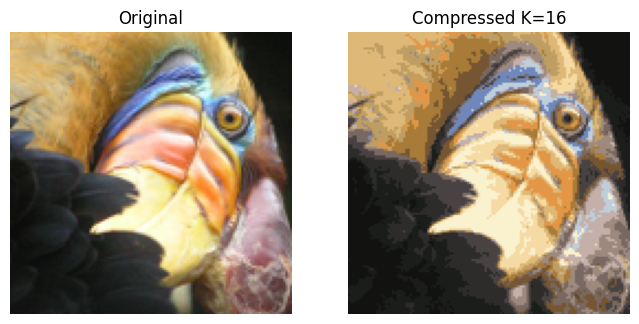

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# --- Start of data loading and preprocessing (from cell 9ee82be2) ---
mat = loadmat('bird_small.mat')
A = mat.get('A', None)
if A is None:
    for k in mat.keys():
        if isinstance(mat[k], np.ndarray) and mat[k].ndim == 3 and mat[k].shape[2] == 3:
            A = mat[k]; break
if A is None:
    raise ValueError('Could not find 3D RGB array in bird_small.mat')
A_norm = A / 255.0
X_img = A_norm.reshape(-1, 3)
# --- End of data loading and preprocessing ---

# Helper functions for K-Means (copied from cell f27d30ba to ensure availability)
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)

def find_closest_centroids(X, centroids):
    diffs = X[:, None, :] - centroids[None, :, :]
    d2 = np.sum(diffs * diffs, axis=2)
    return np.argmin(d2, axis=1)

def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    C = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.size == 0:
            C[k] = X[rng.integers(0, m)]
        else:
            C[k] = pts.mean(axis=0)
    return C

def run_k_means(X, init_C, max_iters=10, rng=None):
    K = init_C.shape[0]
    C = init_C.copy().astype(float)
    history = [C.copy()]
    idx = None
    for _ in range(max_iters):
        idx = find_closest_centroids(X, C)
        C = compute_centroids(X, idx, K, rng=rng)
        history.append(C.copy())
    return C, idx, history

K = 16   # Choose number of colors (e.g., 16) for image compression
ITERS = 10  # Choose iterations for K-Means
rng = np.random.default_rng(0)
C0 = init_centroids(X_img, K, rng)
C_final, idx, hist = run_k_means(X_img, C0, max_iters=ITERS, rng=rng)

# Rebuild compressed pixels and image
X_comp = C_final[idx]  # Map each pixel to its assigned centroid color
A_comp = X_comp.reshape(A.shape)  # Reshape back to original image dimensions

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(A_norm); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(A_comp); plt.title(f'Compressed K={K}') ; plt.axis('off')
plt.show()

## Task 3 - PCA on `ex7data1.mat`
- Load `X` from the file. If the file is missing, the cell will create a synthetic 2D dataset so you can proceed
- Feature normalize: subtract mean and divide by std
- Compute covariance matrix and do SVD with `np.linalg.svd`
- Project onto first principal component and recover back
- Plot original, projection line, and recovered points

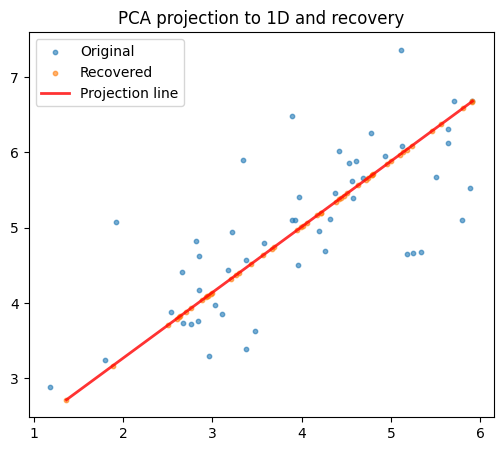

In [8]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

try:
    X = loadmat('ex7data1.mat').get('X', None)
    if X is None:
        raise FileNotFoundError('X not found in mat file')
except Exception as e:
    # Fallback synthetic data
    rng = np.random.default_rng(0)
    t = rng.normal(size=300)
    X = np.c_[t, 0.4*t + rng.normal(scale=0.2, size=t.shape)]

m, n = X.shape

# Feature Normalize
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_norm = (X - mu) / sigma

# Compute covariance and SVD
Sigma = (1 / m) * X_norm.T @ X_norm # Covariance matrix
U, S, Vt = np.linalg.svd(Sigma)  # SVD

# Project to 1D and recover
K_pca = 1 # Project to 1 dimension
U1 = U[:, :K_pca] # First principal component
Z = X_norm @ U1 # Projected data
X_rec_norm = Z @ U1.T # Recovered data in normalized space
X_rec = X_rec_norm * sigma + mu # Scale back to original dimensions

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.6, label='Original')
plt.scatter(X_rec[:,0], X_rec[:,1], s=10, alpha=0.6, label='Recovered')

# To plot the projection line itself for K_pca=1:
# Reconstruct the 2D points corresponding to the min/max projected values
# These points define the ends of the projection line segment
min_z = Z.min()
max_z = Z.max()

line_start_norm = min_z * U[:,0] # U[:,0] is the first principal component vector
line_end_norm = max_z * U[:,0]

line_start_orig = line_start_norm * sigma + mu
line_end_orig = line_end_norm * sigma + mu

plt.plot([line_start_orig[0], line_end_orig[0]],
         [line_start_orig[1], line_end_orig[1]],
         'r-', label='Projection line', alpha=0.8, linewidth=2)

plt.title('PCA projection to 1D and recovery')
plt.legend(); plt.show()